Deep learning for stage prediction

stage 12 and 34

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import KMeansSMOTE
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, f1_score, 
                             precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
import shap

# Load data
data_filtered = pd.read_csv('stage 12 and 34.csv')
name='stage 12 and 34'

# Display the new DataFrame
print(data_filtered)

     ENSG00000240409  ENSG00000186891  ENSG00000206652  ENSG00000158747  \
0           6.340558         6.233669         6.514736        11.291353   
1           5.443781         8.848197         8.145746        13.277786   
2           4.807543         7.487034        11.898779        11.591094   
3           5.528170         7.182070         9.633570        13.386814   
4           7.656880         8.131274         7.126975        12.603596   
..               ...              ...              ...              ...   
413         5.469234         5.381584        10.063063         9.713579   
414         6.807368         7.518390         9.782289        13.288984   
415         5.590217         7.292296        14.513159        13.509887   
416         4.700583         5.862515        11.063485        12.024872   
417         5.440803         7.019552         7.391446        11.578962   

     ENSG00000188257  ENSG00000117215  ENSG00000229162  ENSG00000252947  \
0           4.527250    

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - AUC: 0.6204 - loss: 1.3628 - val_AUC: 0.0000e+00 - val_loss: 0.0239
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - AUC: 0.9699 - loss: 0.3952 - val_AUC: 0.0000e+00 - val_loss: 0.0192
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - AUC: 0.9778 - loss: 0.2533 - val_AUC: 0.0000e+00 - val_loss: 0.0095
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - AUC: 0.9937 - loss: 0.1777 - val_AUC: 0.0000e+00 - val_loss: 0.0022
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - AUC: 0.9995 - loss: 0.0607 - val_AUC: 0.0000e+00 - val_loss: 0.0011
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - AUC: 0.9969 - loss: 0.0728 - val_AUC: 0.0000e+00 - val_loss: 8.3753e-04
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - AUC: 0.9985 - loss: 0.0549 - val_AUC: 0.0000e+00 - val_loss: 4.3503e-04
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - AUC: 0.9981 - loss: 0.0716 - val_AUC: 0.0000e+00 - val_loss: 4.3931e-04
Epoch 9/100


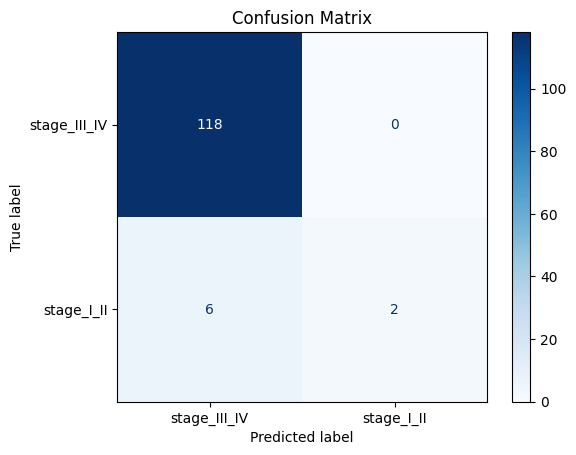

In [2]:
target="label"
X = data_filtered.drop([target], axis=1)  # Drop target variable
y = data_filtered[target]

# Step 2: Remove low variance features
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# Convert back to DataFrame for easier handling
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Step 3: Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Initialize LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 5: Perform KMeans-SMOTE on the training set with adjusted parameters
kmeans_smote = KMeansSMOTE(cluster_balance_threshold=0.1, random_state=42)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# Reshape data for CNN input
X_resampled = np.expand_dims(X_resampled, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# Compute class weights
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Build the CNN model
model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_resampled.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))
model.add(Conv1D(32, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Use sigmoid for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# Train the model
history = model.fit(X_resampled, y_resampled, epochs=100, batch_size=16, validation_split=0.2, class_weight=class_weights)

# Evaluate the model
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()  # Use threshold for binary classification
y_test_labels = y_test  # No need for argmax since y_test is 1D

# Calculate evaluation metrics
auc_score = roc_auc_score(y_test_labels, y_pred_proba)
f1 = f1_score(y_test_labels, y_pred)
precision = precision_score(y_test_labels, y_pred)
recall = recall_score(y_test_labels, y_pred)

# Display results
print(f"AUC Score: {auc_score:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Show confusion matrix
cm = confusion_matrix(y_test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()



Catboost for stage presictin

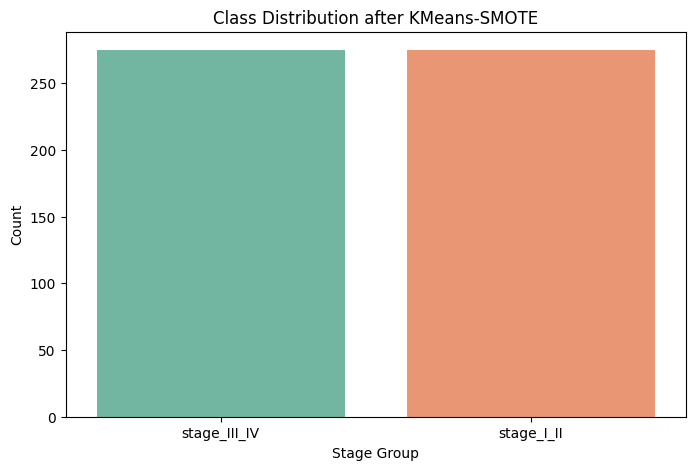

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'depth': 4, 'iterations': 100, 'learning_rate': 0.2}
Best CatBoost Classifier Performance:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       118
           1       0.40      0.25      0.31         8

    accuracy                           0.93       126
   macro avg       0.68      0.61      0.64       126
weighted avg       0.92      0.93      0.92       126

Confusion Matrix:
[[115   3]
 [  6   2]]
AUC: 0.71
Matthews Correlation Coefficient (MCC): 0.28


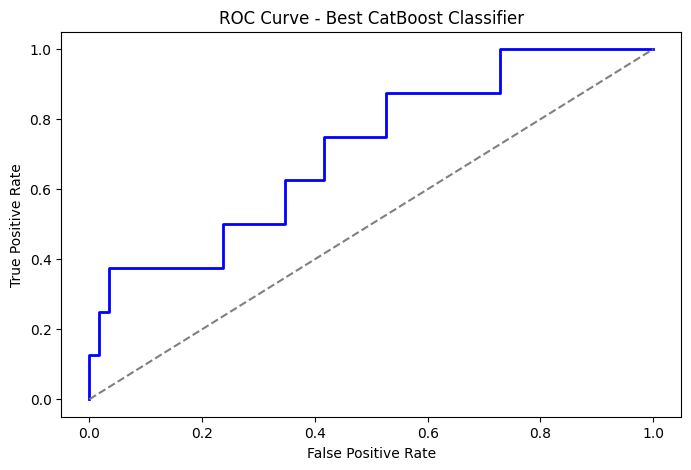

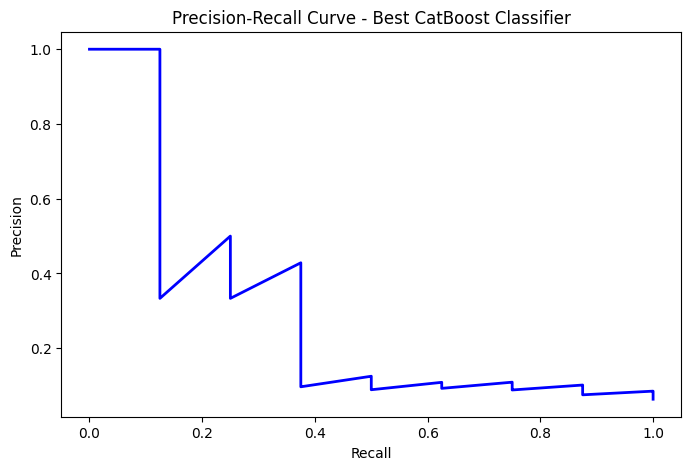

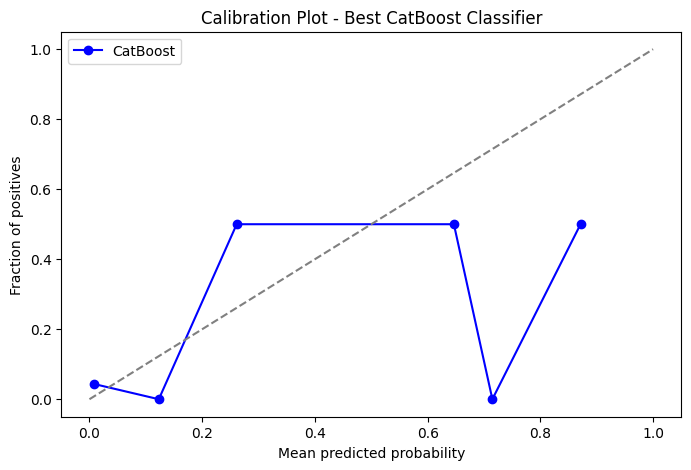

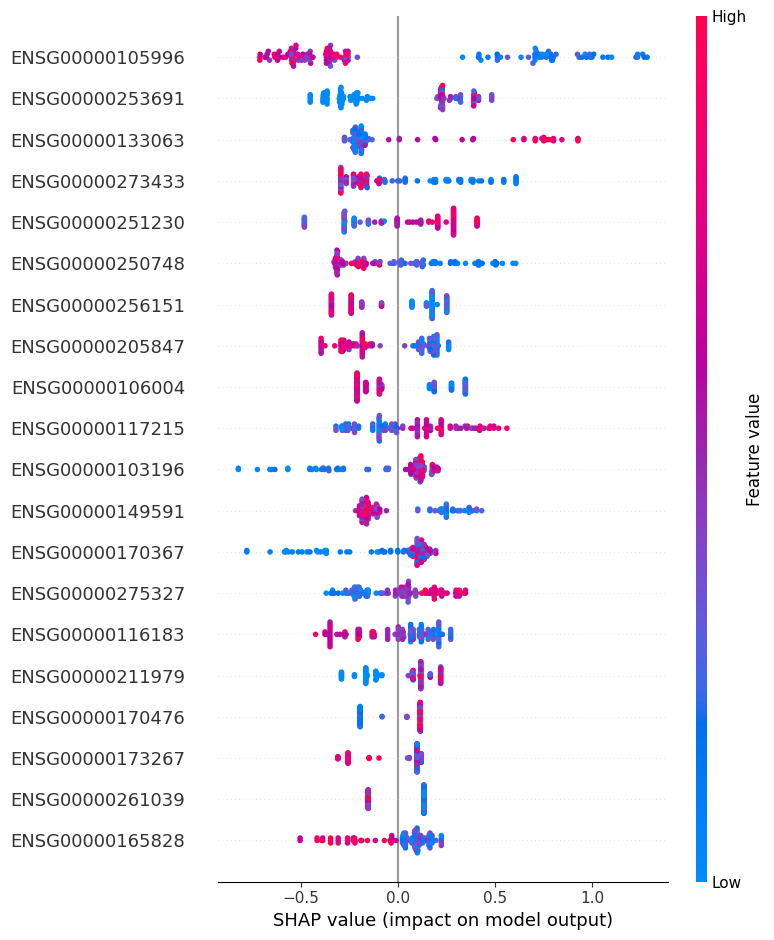

Top 100 most important features saved to 'top_130_shap_features.csv'


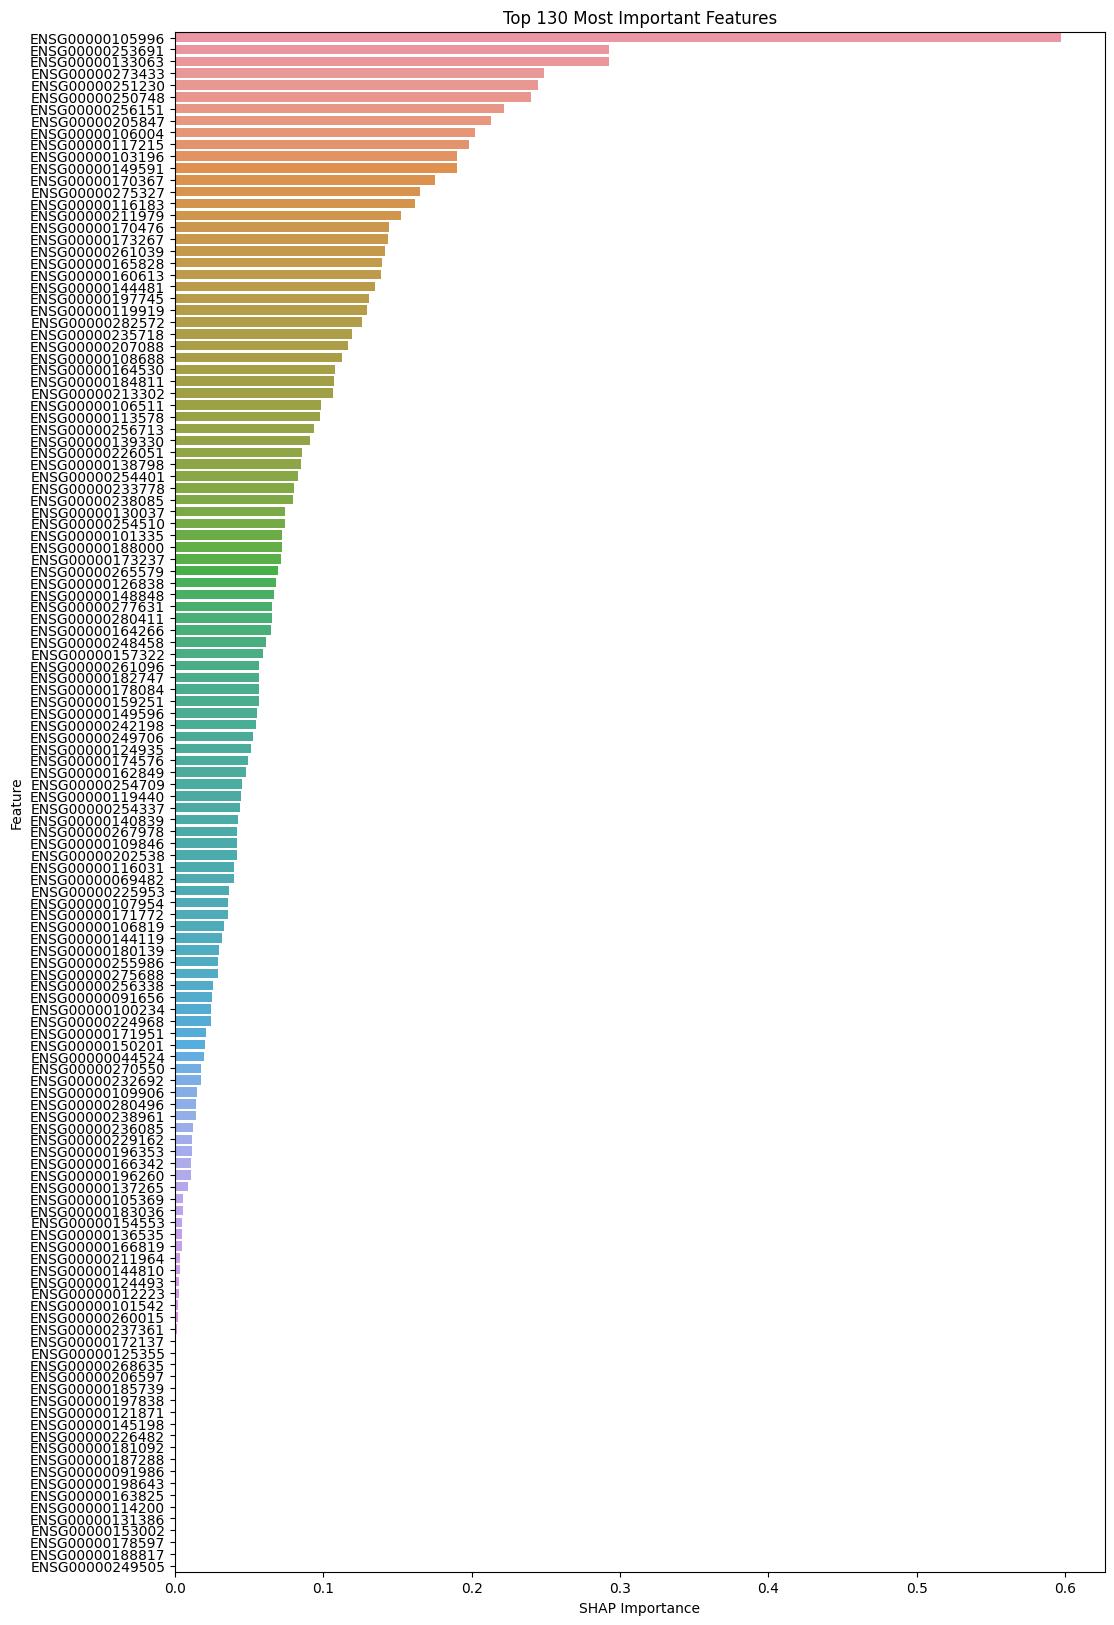

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import KMeansSMOTE
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, matthews_corrcoef, precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from catboost import CatBoostClassifier
import shap
target="label"
# Load data
data_filtered = pd.read_csv('stage 12 and 34.csv')

# Step 1: Prepare features and target variable
X = data_filtered.drop([target], axis=1)  # Drop target variable
y = data_filtered[target]

# Step 2: Remove low variance features
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# Convert back to DataFrame for easier handling
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Step 3: Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Initialize LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 5: Perform KMeans-SMOTE on the training set with adjusted parameters
kmeans_smote = KMeansSMOTE(cluster_balance_threshold=0.1, random_state=42)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# Visualize class distribution after KMeans-SMOTE
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, palette='Set2')
plt.title('Class Distribution after KMeans-SMOTE')
plt.xlabel('Stage Group')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=label_encoder.classes_)
plt.show()

# Define parameter grid for CatBoost
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [4, 6, 8]
}

# Initialize GridSearchCV with focus on F1 score for minority class
grid_search = GridSearchCV(estimator=CatBoostClassifier(random_state=42, verbose=0),
                           param_grid=param_grid,
                           cv=3,
                           scoring='f1',
                           n_jobs=-1,
                           verbose=1)

# Fit the model
grid_search.fit(X_resampled, y_resampled)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
print("Best CatBoost Classifier Performance:")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

# Compute AUC score
auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f'AUC: {auc_best:.2f}')

# Calculate additional metrics
mcc = matthews_corrcoef(y_test, y_pred_best)
print(f'Matthews Correlation Coefficient (MCC): {mcc:.2f}')

# Plot ROC curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(fpr_best, tpr_best, color='blue', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best CatBoost Classifier')
plt.show()

# Plot Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Best CatBoost Classifier')
plt.show()

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_best, n_bins=10)
plt.figure(figsize=(8, 5))
plt.plot(prob_pred, prob_true, marker='o', color='blue', label='CatBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot - Best CatBoost Classifier')
plt.legend()
plt.show()

# SHAP summary plots
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# SHAP summary plot (beeswarm)
plt.figure(figsize=(15, 10))  # Increase the plot size
shap.summary_plot(shap_values, X_test)

# Determine the top 100 most important features based on SHAP values
shap_importances = np.abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': shap_importances})
shap_importance_df = shap_importance_df.sort_values(by='importance', ascending=False).head(130)

# Save the top 100 features to a CSV file
shap_importance_df.to_csv(name+'top_130_shap_features.csv', index=False)
print(f"Top 100 most important features saved to 'top_130_shap_features.csv'")

# Plot top 100 most important features
plt.figure(figsize=(12, 20))  # Increase the plot size
sns.barplot(x='importance', y='feature', data=shap_importance_df)
plt.title('Top 130 Most Important Features')
plt.xlabel('SHAP Importance')
plt.ylabel('Feature')
plt.show()


In [4]:
import pandas as pd
import numpy as np

# Assuming shap_importance_df contains the top 130 feature names
top_130_features = shap_importance_df['feature'].tolist()

# Filter X to retain only the top 130 features
X_top_130 = X[top_130_features]

# Combine X and y into a single DataFrame
final_dataframe = pd.concat([X_top_130, pd.Series(y, name='label')], axis=1)

# Save the DataFrame to a CSV file (optional)
final_dataframe.to_csv('top_130_features_dataset.csv', index=False)

# Display the DataFrame structure
print("DataFrame with top 130 features:")
print(final_dataframe.head())


DataFrame with top 130 features:
   ENSG00000105996  ENSG00000253691  ENSG00000133063  ENSG00000273433  \
0        -0.473016         0.260374         0.779683        -1.014592   
1        -1.158444        -0.576586         3.217836        -0.791544   
2         2.845615         0.744916         0.015279         3.043844   
3         0.258939         0.808323        -0.608322         0.165670   
4        -0.689181        -0.576586        -0.679470        -0.605309   

   ENSG00000251230  ENSG00000250748  ENSG00000256151  ENSG00000205847  \
0        -1.555332        -1.622019         1.202328         0.527664   
1         0.904486         0.869538         0.852683        -0.004818   
2         0.406306        -1.173005        -0.844088        -1.803489   
3        -0.104611         0.136482        -0.265822         0.846141   
4        -0.560139        -0.037430         0.501695        -0.759478   

   ENSG00000106004  ENSG00000117215  ...  ENSG00000091986  ENSG00000198643  \
0        -0

Features (X):
   ENSG00000105996  ENSG00000253691  ENSG00000133063  ENSG00000273433  \
0        -0.473016         0.260374         0.779683        -1.014592   
1        -1.158444        -0.576586         3.217836        -0.791544   
2         2.845615         0.744916         0.015279         3.043844   
3         0.258939         0.808323        -0.608322         0.165670   
4        -0.689181        -0.576586        -0.679470        -0.605309   

   ENSG00000251230  ENSG00000250748  ENSG00000256151  ENSG00000205847  \
0        -1.555332        -1.622019         1.202328         0.527664   
1         0.904486         0.869538         0.852683        -0.004818   
2         0.406306        -1.173005        -0.844088        -1.803489   
3        -0.104611         0.136482        -0.265822         0.846141   
4        -0.560139        -0.037430         0.501695        -0.759478   

   ENSG00000106004  ENSG00000117215  ...  ENSG00000187288  ENSG00000091986  \
0        -0.914866         0.2

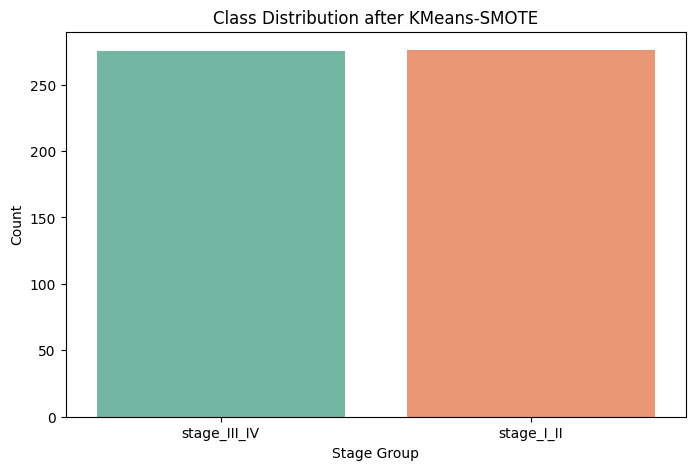

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'depth': 4, 'iterations': 100, 'learning_rate': 0.1}
Best CatBoost Classifier Performance:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       118
           1       0.67      0.25      0.36         8

    accuracy                           0.94       126
   macro avg       0.81      0.62      0.67       126
weighted avg       0.93      0.94      0.93       126

Confusion Matrix:
[[117   1]
 [  6   2]]
AUC: 0.76
Matthews Correlation Coefficient (MCC): 0.39


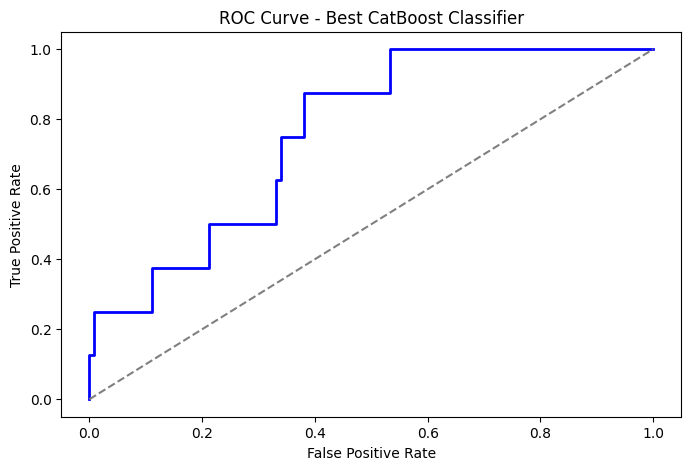

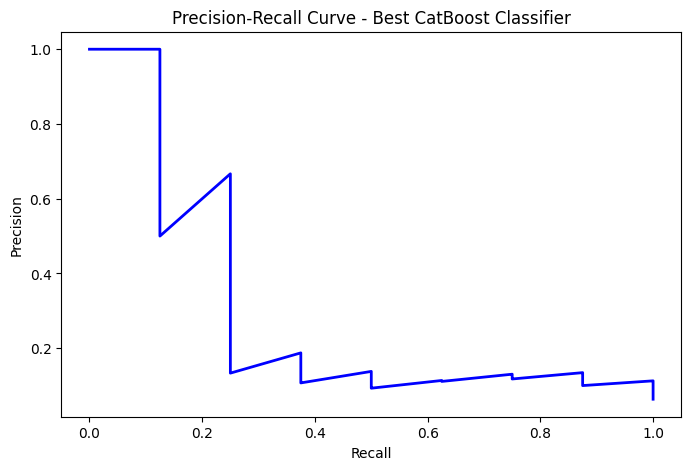

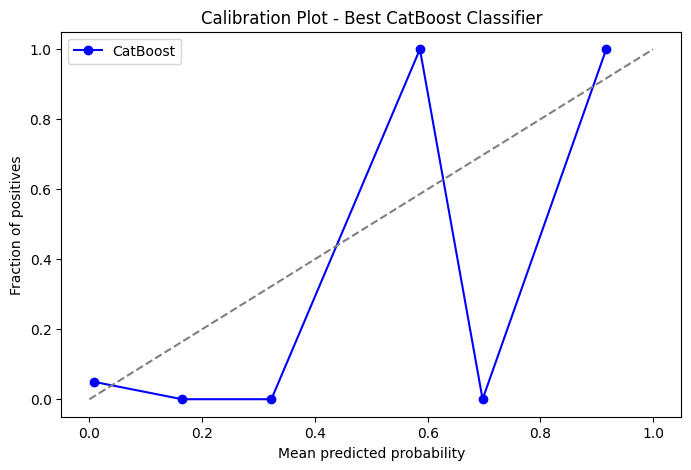

In [5]:
# Assuming 'label' is the target column in final_dataframe
y = final_dataframe['label']  # Extract target variable

# Extract all other columns as features
X = final_dataframe.drop(columns=['label'])

# Display the structure of X and y
print("Features (X):")
print(X.head())
print("\nTarget Variable (y):")
print(y.head())

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 5: Perform KMeans-SMOTE on the training set with adjusted parameters
kmeans_smote = KMeansSMOTE(cluster_balance_threshold=0.1, random_state=42)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# Visualize class distribution after KMeans-SMOTE
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, palette='Set2')
plt.title('Class Distribution after KMeans-SMOTE')
plt.xlabel('Stage Group')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=label_encoder.classes_)
plt.show()

# Define parameter grid for CatBoost
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [4, 6, 8]
}

# Initialize GridSearchCV with focus on F1 score for minority class
grid_search = GridSearchCV(estimator=CatBoostClassifier(random_state=42, verbose=0),
                           param_grid=param_grid,
                           cv=3,
                           scoring='f1',
                           n_jobs=-1,
                           verbose=1)

# Fit the model
grid_search.fit(X_resampled, y_resampled)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
print("Best CatBoost Classifier Performance:")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

# Compute AUC score
auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f'AUC: {auc_best:.2f}')

# Calculate additional metrics
mcc = matthews_corrcoef(y_test, y_pred_best)
print(f'Matthews Correlation Coefficient (MCC): {mcc:.2f}')

# Plot ROC curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(fpr_best, tpr_best, color='blue', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best CatBoost Classifier')
plt.show()

# Plot Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Best CatBoost Classifier')
plt.show()

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_best, n_bins=10)
plt.figure(figsize=(8, 5))
plt.plot(prob_pred, prob_true, marker='o', color='blue', label='CatBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot - Best CatBoost Classifier')
plt.legend()
plt.show()
